# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

import pandas as pd

sys.path.append("..")

import importlib as imp

import warnings
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct

import cmasher as cmr
import plots

import experiment_settings
import mahalanobis
from build_data import build_hurricane_data
import data_info

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "16 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis_plots/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
dpiFig = 300.0
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
# EXP_NAME_VEC = ("centered_bivariate_normal_101_EPCP24",
#                 "centered_bivariate_normal_102_EPCP48",
#                 "centered_bivariate_normal_103_EPCP72",
#                 "centered_bivariate_normal_104_EPCP96",
#                 "centered_bivariate_normal_105_EPCP120",
#                 )
EXP_NAME_VEC = ("centered_bivariate_normal_201_AL24",
                "centered_bivariate_normal_202_AL48",
                "centered_bivariate_normal_203_AL72",
                "centered_bivariate_normal_204_AL96",
                "centered_bivariate_normal_205_AL120",
                )

RNG_SEED = 123
TESTING_YEAR = 2018
LONGITUDE_SCALING = -1. #all longitudes are in degrees west in the dataset

In [5]:
# GET PREDICTIONS
df_pred_train = pd.DataFrame()
df_pred_valtest = pd.DataFrame()
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    network_seed = RNG_SEED
    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    (
        data_summary,
        x_train,
        onehot_train,
        x_val,
        onehot_val,
        x_test,
        onehot_test,
        x_valtest,
        onehot_valtest,
        df_train,
        df_val,
        df_test,
        df_valtest,
    ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

    # load the model
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
    )
    model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)

    # make dictionary of the predictions
    pred_dict_lead = {"exp_name": exp_name,
                      "testing_year": TESTING_YEAR,
                      }

    # copy dataframe and fill in the predictions
    df_train_lt = df_train.copy()
    df_valtest_lt = df_valtest.copy()
    df_test_lt = df_test.copy()

    df_train_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_train)
    df_valtest_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_valtest)
    df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)

    df_train_lt["exp_name"] = exp_name
    df_valtest_lt["exp_name"] = exp_name
    df_test_lt["exp_name"] = exp_name

    # correct longitude for the Atlantic or Pacific
    df_train_lt["LONC"] = df_train_lt["LONC"]*LONGITUDE_SCALING
    df_valtest_lt["LONC"] = df_valtest_lt["LONC"]*LONGITUDE_SCALING
    df_test_lt["LONC"] = df_test_lt["LONC"]*LONGITUDE_SCALING

    # append to main dataframe
    df_pred_train = pd.concat([df_pred_train, df_train_lt], axis=0)
    df_pred_valtest = pd.concat([df_pred_valtest, df_valtest_lt], axis=0)
    df_pred_test = pd.concat([df_pred_test, df_test_lt], axis=0)

centered_bivariate_normal_201_AL24
centered_bivariate_normal_202_AL48
centered_bivariate_normal_203_AL72
centered_bivariate_normal_204_AL96
centered_bivariate_normal_205_AL120


In [6]:
# error('here')

# Plot Results

In [7]:
plots.set_plot_rc()

120 dataframe is empty


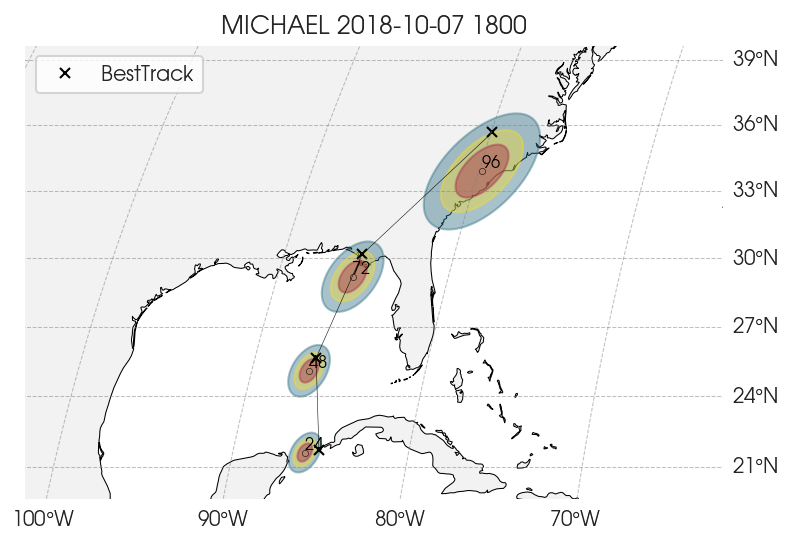

In [8]:
imp.reload(mahalanobis)
imp.reload(plots)

fig = plt.figure(dpi=150,)
ax = fig.add_subplot(1,1,1,projection=ct.crs.EqualEarth(central_longitude=0.))

# storm = {"storm_name": "NORMAN",
#          "pred_time": 90306,
#          "extent": [-165,-135,5,35],
#          }
storm = {"storm_name": "MICHAEL",
         "pred_time": 100718,
         "extent": [-100,-70,15,45],
         }

df_storm = df_pred_test.loc[(df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])]
details = plots.plot_leadtime_predictions(df_storm,
                                          ax=ax,
                                          leadtimes=(24,48,72,96,120),
                                          contours=(.25,.5,.75),
                                          )
# ax.set_global()
ax.set_extent(storm["extent"],crs=ct.crs.PlateCarree())

# save the figure
plt.savefig(FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
            dpi=dpiFig,
            bbox_inches='tight',
            )
plt.show()

In [9]:
df_storm

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OBDV,DSDV,LGDV,...,EMDY,EGDY,HWDY,LATC,mu_u,mu_v,sigma_u,sigma_v,rho,exp_name
179,AL14,MICHAEL,2018,100718,24,40.0,4,12.8,1.8,-3.2,...,-19.4,-41.7,36.1,21.6,-0.0,0.0,56.743309,56.394215,0.166976,centered_bivariate_normal_201_AL24
73,AL14,MICHAEL,2018,100718,48,40.0,4,25.2,1.2,-5.8,...,-105.5,-61.1,150.0,25.1,-0.0,0.0,73.006439,74.302910,0.144718,centered_bivariate_normal_202_AL48
68,AL14,MICHAEL,2018,100718,72,40.0,4,65.5,8.5,9.5,...,-247.2,-102.8,308.3,29.2,0.0,0.0,107.552872,103.120148,0.180055,centered_bivariate_normal_203_AL72
95,AL14,MICHAEL,2018,100718,96,40.0,4,6.5,-3.5,-3.5,...,-483.3,-183.3,549.9,33.9,-0.0,0.0,199.005402,174.770874,0.316546,centered_bivariate_normal_204_AL96
